# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score ,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import pickle
import plotly.graph_objects as go
import plotly.express as px

# TASK 1 — Data Loading & Exploratory Analysis

In [2]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#Here the totalcharges are float values but it is noted as object
#Also we dont need the customerid  so we remove it
df=df.drop(columns=["customerID"])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#printing the unique values fromalll columns
for col in df.columns:
  print(col,df[col].unique())
  print('--'*30)

gender ['Female' 'Male']
------------------------------------------------------------
SeniorCitizen [0 1]
------------------------------------------------------------
Partner ['Yes' 'No']
------------------------------------------------------------
Dependents ['No' 'Yes']
------------------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
------------------------------------------------------------
PhoneService ['No' 'Yes']
------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
------------------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------

In [6]:
df[df["TotalCharges"]==" "]#there are blank spaces that cannot be converted into float type


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
#We can replace the empty spaces with 0.0
df["TotalCharges"]=df["TotalCharges"].replace(" ","0.0")
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [8]:
df.info()#Totalcharges are now float and consists no blank values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
#Checking the count distribution of the churn column
churn_count=df["Churn"].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Churn Value Counts:",churn_count)
print("\nChurn Value Percentage:",churn_pct)
#Churn is imbalanced with 73% of not churn and 26% of churn values


Churn Value Counts: Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Value Percentage: Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


 Summary statistics for numerical columns

In [10]:
df.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762,2279.734
std,0.369,24.559,30.090,2266.794
min,0.000,0.000,18.250,0.000
25%,0.000,9.000,35.500,398.550
50%,0.000,29.000,70.350,1394.550
75%,0.000,55.000,89.850,3786.600
max,1.000,72.000,118.750,8684.800


correlation heatmap of numerical features

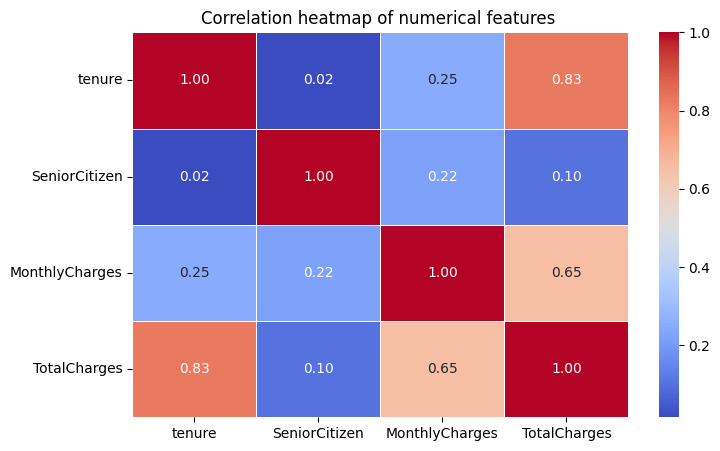

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["tenure","SeniorCitizen","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation heatmap of numerical features ")
plt.show()

# TASK 2 — Data Preprocessing & Feature Engineering

Since i have already done TotalCharges to numeric — handle coercion errors , I am skipping this part


Label encodeing of Categorical columns

In [12]:
object_columns=df.select_dtypes(include='object').columns
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [13]:
encoders={}
#apply label encoding and store the encoders
for column in object_columns:
  label_encoder=LabelEncoder()
  df[column]=label_encoder.fit_transform(df[column])
  encoders[column]=label_encoder
#save the encoders into a pickel file
with open("encoders.pkl","wb") as f:
  pickle.dump(encoders,f)
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**2 new features**

In [15]:
#1st feature - ChargesPerMonth
df[" ChargesPerMonth"] = df["TotalCharges"] / df["tenure"]
df[" ChargesPerMonth"] = df[" ChargesPerMonth"].fillna(0)#2nd feature - SeniorWithNoSupport
df["SeniorWithNoSupport"]=(
    (df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')
).astype(int)
#3rd feature - HighValueLowTenure — high monthly charges but short tenure
df['HighValueLowTenure'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['tenure'] < 12)
).astype(int)

df.head(3)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,SeniorWithNoSupport,HighValueLowTenure
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,29.850000,0,0
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,55.573529,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,54.075000,0,0


Every column is encoded into numerical type & i used lable encoder for this because its better than onehot encoding and its also simple comapered to onehot encoding
while using for model like random forest and xgboost label encoder is the better option to go with

In [16]:
df.describe().round(2)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,SeniorWithNoSupport,HighValueLowTenure
count,7043.0,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,...,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00
mean,0.5,0.16,0.48,0.30,32.37,0.9,0.94,0.87,0.79,0.91,...,0.99,0.69,0.59,1.57,64.76,2279.73,0.27,64.70,0.0,0.11
std,0.5,0.37,0.50,0.46,24.56,0.3,0.95,0.74,0.86,0.88,...,0.89,0.83,0.49,1.07,30.09,2266.79,0.44,30.27,0.0,0.31
min,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,18.25,0.00,0.00,0.00,0.0,0.00
25%,0.0,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,35.50,398.55,0.00,35.65,0.0,0.00
50%,1.0,0.00,0.00,0.00,29.00,1.0,1.00,1.00,1.00,1.00,...,1.00,0.00,1.00,2.00,70.35,1394.55,0.00,70.30,0.0,0.00
75%,1.0,0.00,1.00,1.00,55.00,1.0,2.00,1.00,2.00,2.00,...,2.00,1.00,1.00,2.00,89.85,3786.60,1.00,90.17,0.0,0.00
max,1.0,1.00,1.00,1.00,72.00,1.0,2.00,2.00,2.00,2.00,...,2.00,2.00,1.00,3.00,118.75,8684.80,1.00,121.40,0.0,1.00


In [17]:
X = df.drop(columns=['Churn'])
y = df['Churn']
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)#80%Train :20%Test


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Ensure all numerical columns are included, including your new features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', ' ChargesPerMonth']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# TASK 3 — Model Training & Comparison


Model 1: Logistic Regression

In [19]:
#3 models are used
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(eval_metric='logloss',
                                          random_state=42, n_jobs=-1)
}
#Storing the results of the training in a dict
results={}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[model_name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }
    print(f"{model_name} is trained and evaluated. ")

# Summary Table
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, res in results.items()
}).T.round(4)
print("Model evaluation")
metrics_df


Logistic Regression is trained and evaluated. 
Random Forest is trained and evaluated. 
XGBoost is trained and evaluated. 
Model evaluation


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7970,0.6477,0.5160,0.5744,0.8397
Random Forest,0.7928,0.6434,0.4920,0.5576,0.8282
XGBoost,0.7828,0.6104,0.5027,0.5513,0.8216


Confusion Matrix for each model side-by-side

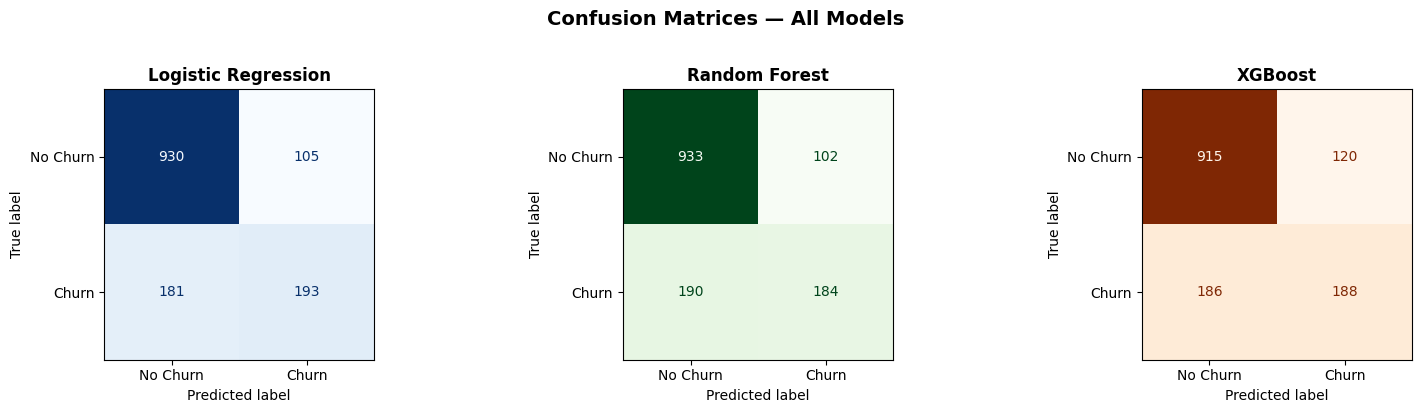

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['Blues', 'Greens', 'Oranges']

for ax, (name, res), cmap in zip(axes, results.items(), colors):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 ROC Curve for all 3 models

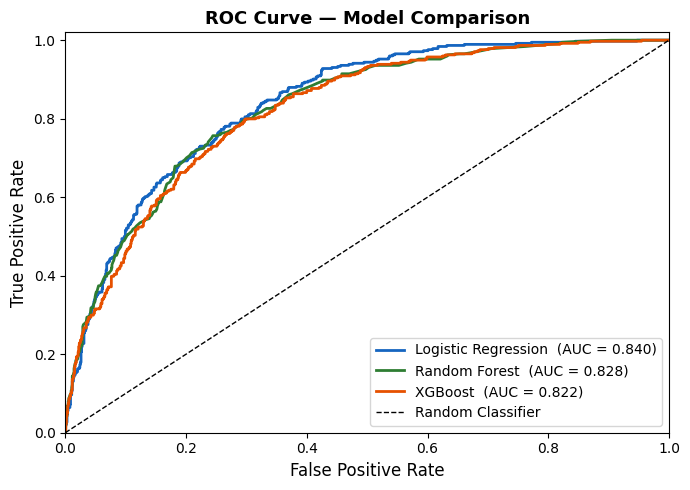

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ['#1565C0', '#2E7D32', '#E65100']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

Basic hyperparameter tuning

In [22]:
# Using RandomizedSearchCV for efficiency
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 4, 5, 6],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5]
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

rscv = RandomizedSearchCV(
    xgb_base, param_grid, n_iter=30,
    scoring='roc_auc', cv=StratifiedKFold(n_splits=5),
    random_state=42, n_jobs=-1, verbose=1
)

rscv.fit(X_train, y_train)
best_xgb = rscv.best_estimator_
print(f'\n✅ Best parameters: {rscv.best_params_}')

# Evaluate tuned model
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]
print(f'Tuned XGBoost — F1: {f1_score(y_test, y_pred_tuned):.4f}  |  ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')

# Update results with tuned model
results['XGBoost']['model']  = best_xgb
results['XGBoost']['y_pred'] = y_pred_tuned
results['XGBoost']['y_prob'] = y_prob_tuned
best_model = best_xgb
best_model_name = 'XGBoost (Tuned)'

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:33:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Tuned XGBoost — F1: 0.5367  |  ROC-AUC: 0.8459


# TASK 4 — Customer Risk Segmentation

In [23]:
# Get churn probabilities for the test set
churn_proba = best_model.predict_proba(X_test)[:, 1]

seg_df = df.iloc[X_test.index].copy().reset_index(drop=True)
seg_df['TotalCharges'] = pd.to_numeric(seg_df['TotalCharges'], errors='coerce').fillna(seg_df['MonthlyCharges'])
seg_df['ChurnProb'] = churn_proba
seg_df['Actual_Churn'] = y_test.values

# Segment by probability thresholds
def assign_tier(prob):
    if prob >= 0.70:
        return '🔴 High Risk'
    elif prob >= 0.40:
        return '🟡 Medium Risk'
    else:
        return '🟢 Low Risk'

seg_df['RiskTier'] = seg_df['ChurnProb'].apply(assign_tier)

tier_counts = seg_df['RiskTier'].value_counts()
print('Customer Count per Risk Tier:')
print(tier_counts)

Customer Count per Risk Tier:
RiskTier
🟢 Low Risk       1039
🟡 Medium Risk     306
🔴 High Risk        64
Name: count, dtype: int64


 Computing average MonthlyCharges, average tenure, and Contract type distribution


In [24]:
risk_group_order = ['🔴 High Risk', '🟡 Medium Risk', '🟢 Low Risk']

# Numeric summaries
risk_group_numeric = seg_df.groupby('RiskTier')[['MonthlyCharges', 'tenure']].mean().round(2)
risk_group_numeric = risk_group_numeric.reindex(risk_group_order)
print('\nAverage MonthlyCharges & Tenure per Risk Group:')
print(risk_group_numeric)

# Contract type distribution
risk_group_contract = seg_df.groupby(['RiskTier', 'Contract']).size().unstack(fill_value=0)
risk_group_contract = risk_group_contract.reindex(risk_group_order)
print('\nContract Type Distribution per Risk Group:')
print(risk_group_contract)


Average MonthlyCharges & Tenure per Risk Group:
               MonthlyCharges  tenure
RiskTier                             
🔴 High Risk             85.36    2.64
🟡 Medium Risk           76.04   13.13
🟢 Low Risk              59.26   39.25

Contract Type Distribution per Risk Group:
Contract         0    1    2
RiskTier                    
🔴 High Risk     64    0    0
🟡 Medium Risk  306    0    0
🟢 Low Risk     403  300  336


 Grouped bar chart

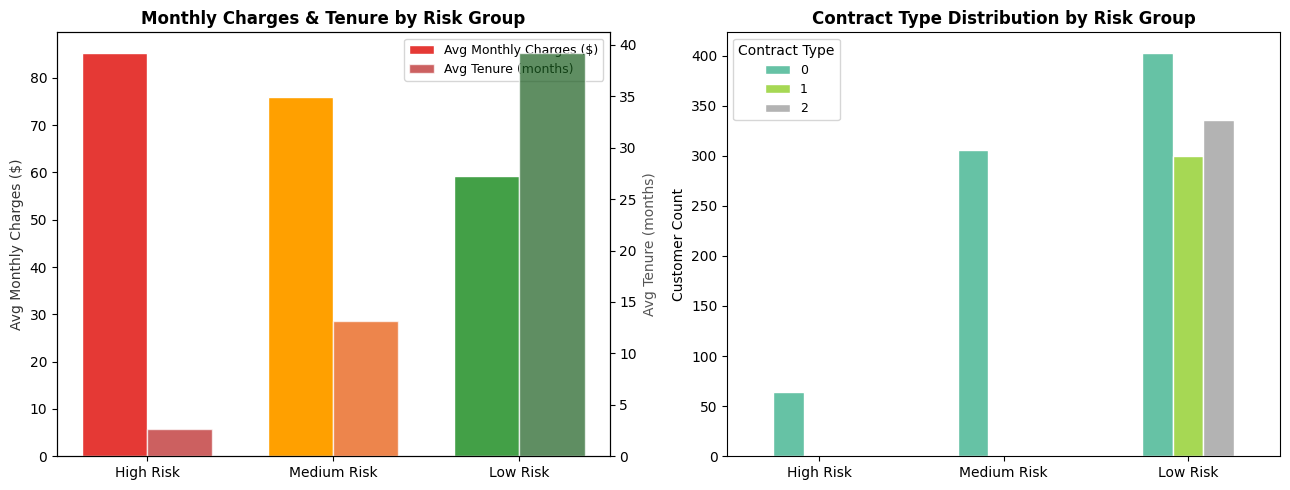

In [25]:
risk_colors = {'🔴 High Risk': '#E53935', '🟡 Medium Risk': '#FFA000', '🟢 Low Risk': '#43A047'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart A: Avg MonthlyCharges & Tenure
x = np.arange(len(risk_group_order))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, risk_group_numeric['MonthlyCharges'], width, label='Avg Monthly Charges ($)',
               color=['#E53935', '#FFA000', '#43A047'], edgecolor='white')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, risk_group_numeric['tenure'], width, label='Avg Tenure (months)',
                color=['#B71C1C', '#E65100', '#1B5E20'], edgecolor='white', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['High Risk', 'Medium Risk', 'Low Risk'])
ax.set_ylabel('Avg Monthly Charges ($)', color='#333')
ax2.set_ylabel('Avg Tenure (months)', color='#555')
ax.set_title('Monthly Charges & Tenure by Risk Group', fontweight='bold')
lines = [bars1, bars2]
ax.legend(lines, [b.get_label() for b in lines], loc='upper right', fontsize=9)

# Chart B: Contract Distribution
ax3 = axes[1]
risk_group_contract.plot(kind='bar', ax=ax3, edgecolor='white', colormap='Set2')
ax3.set_title('Contract Type Distribution by Risk Group', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Customer Count')
ax3.set_xticklabels(['High Risk', 'Medium Risk', 'Low Risk'], rotation=0)
ax3.legend(title='Contract Type', fontsize=9)

plt.tight_layout()
plt.show()

# TASK 5 — Visualizations  4 Charts


Chart 1 — Feature Importance Top 10 from XGBoost

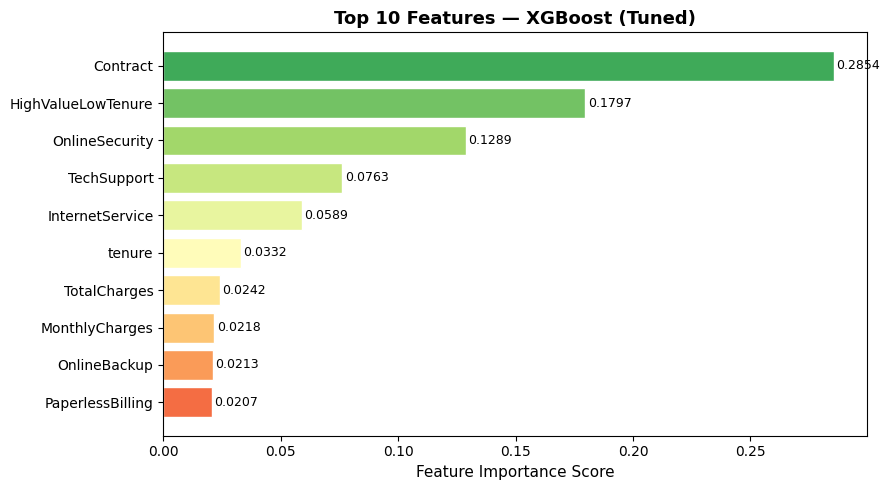

In [26]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index, top10.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.85, 10)), edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Top 10 Features — XGBoost (Tuned)', fontweight='bold', fontsize=13)
for bar, val in zip(bars, top10.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

Chart 2 — Churn Rate by Contract Type

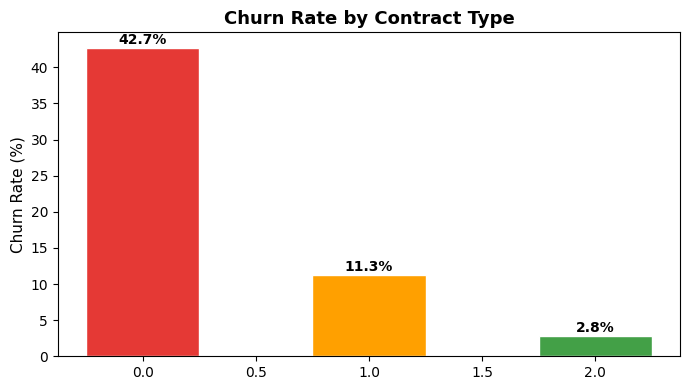

In [27]:
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 1).mean() * 100  # Assuming 'Yes' is encoded as 1
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#E53935', '#FFA000', '#43A047']
ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
       color=bar_colors, edgecolor='white', width=0.5)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=13)
for bar, val in zip(ax.patches, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Chart 3 — Tenure Distribution)

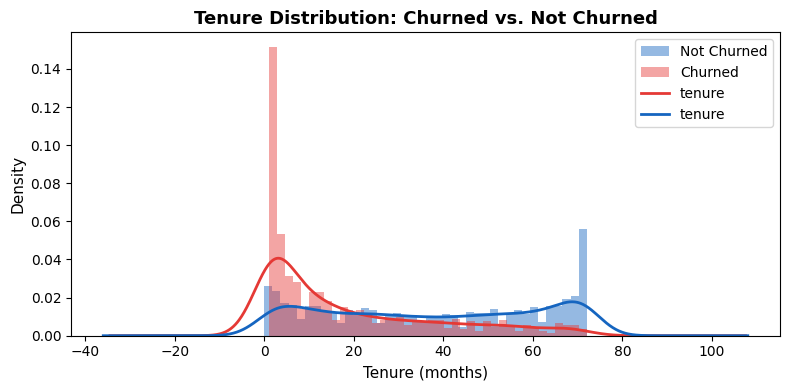

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

churned    = df[df['Churn'] == 1]['tenure'] # Corrected to use numerical label 1 for 'Yes'
not_churned = df[df['Churn'] == 0]['tenure'] # Corrected to use numerical label 0 for 'No'

ax.hist(not_churned, bins=40, alpha=0.45, color='#1565C0', label='Not Churned', density=True)
ax.hist(churned,    bins=40, alpha=0.45, color='#E53935', label='Churned', density=True)
churned.plot(kind='kde', ax=ax, color='#E53935', lw=2)
not_churned.plot(kind='kde', ax=ax, color='#1565C0', lw=2)

ax.set_xlabel('Tenure (months)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Tenure Distribution: Churned vs. Not Churned', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Chart 4: Risk tier pie chart

In [29]:
risk_group_counts_ordered = seg_df['RiskTier'].value_counts().reindex(risk_group_order)

fig = go.Figure(go.Pie(
    labels=['High Risk', 'Medium Risk', 'Low Risk'],
    values=risk_group_counts_ordered.values,
    hole=0.55,
    marker=dict(colors=['#E53935', '#FFA000', '#43A047'],
                line=dict(color='white', width=2)),
    textinfo='label+percent+value',
    hovertemplate='%{label}<br>Count: %{value}<br>Share: %{percent}<extra></extra>'
))
fig.update_layout(
    title=dict(text='Customer Risk Tier Distribution', font=dict(size=16), x=0.5),
    showlegend=True,
    width=550, height=450
)
fig.show()


Interactive scatter plot using Plotly

In [30]:
scatter_df = seg_df.copy()
scatter_df['Churn_Label'] = scatter_df['Actual_Churn'].map({1: 'Churned', 0: 'Not Churned'})

fig = px.scatter(
    scatter_df,
    x='tenure',
    y='MonthlyCharges',
    color='Churn_Label',
    color_discrete_map={'Churned': '#E53935', 'Not Churned': '#1565C0'},
    opacity=0.65,
    size='ChurnProb',
    hover_data=['Contract', 'ChurnProb', 'RiskTier'],
    title='MonthlyCharges vs. Tenure — Colored by Churn (Bubble Size = Churn Probability)',
    labels={'tenure': 'Tenure (months)', 'MonthlyCharges': 'Monthly Charges ($)'}
)
fig.update_layout(width=900, height=500, title_x=0.5)
fig.show()

# TASK 6 — Insights & Business Recommendations




---
1.  Which model performed best and why did you select it?

---
    Among the 3 model if compared on metrics ,Linear regression got the high metrics score as ROC-AOC ,Accuracy,F1 score but if compared on large scale of data the Linear Regression model might score lower compared to the XGboost model .
    Also features like Tenure and Contract Type has more of Linear Dependancy .
    So in short scale prediction the Linear Regressionmodel will be good choice
    but in large scale prediction XGBoost is a better model


---
2.  What are the top 3 factors driving customer churn according to your model?
---
*  **Contract Type:**
    Based on the type of Contract they are taken:
    1.People who have taken 1 month plan has a much higher churn(43%) compared to people who have taken Yearly plan has a lower churn (11%) and 2 year plan (3%).
*   **Tenure:**
    First impression is the best impression ,people who has churned from the monthly plan is mostly due to the disappointment in the  service provided by the company or the product .
    People who have purchased large tensures have maintained their relationship with company.

    So we need to provide 3 month plans for the people who are not able to buy the yearly

*   **MonthlyCharges :**
    High-charge customers with no long-term contracts are far more likely to churn, especially when paired with low tenure and lack of value-added services.



---


3.   What do High Risk customers have in common?
    High-risk customers have churn probability ≥ 0.70 are predominantly on month-to-month contracts, have short tenures typically under 12 months, and carry above-average monthly charges. They often lack services like TechSupport or OnlineSecurity, and are more likely to be senior citizens without support services.

---


4.  Write 2 specific, actionable business recommendations the company should
    implement ?

    Early Loyalty Program : Automatically enroll new customers with high churn probability scores into a targeted loyalty program. Offer a 10–15% discount or a free service upgrade (e.g., TechSupport or OnlineBackup) at the 3-month mark if they upgrade to a one-year contract. This directly addresses the two biggest churn drivers — short tenure and month-to-month contracts — simultaneously.

    Personalized care for High-Risk Segment:
    Run a monthly batch of the churn model on the active customer base. Flag all customers in the High Risk tier and assign them to a dedicated retention team. Personalize outreach based on their specific gap: if they lack TechSupport, offer a 30-day free trial; if they have high charges, present a comparable plan at a lower price. Proactive retention is 5× cheaper than re-acquiring lost customers.

---


5.  What are the limitations of your model? What could be improved with more data or time?
    The model does not account for temporal patterns — customer behavior changes over time, and a time-series approach (e.g., survival analysis) could better capture churn timing.
    No customer satisfaction or NPS data is available. Including support ticket volume or satisfaction scores would significantly improve recall on high-risk customers.
    The dataset is from a single telecom provider and may not generalize to other industries or geographies.
    With more time, SHAP (SHapley Additive exPlanations) values would allow per-customer explainability — essential for a real-world retention team.









In [31]:
!pip freeze > requirements.txt
print('✅ requirements.txt generated.')
!head -20 requirements.txt

✅ requirements.txt generated.
absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
